In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/bartek358/train-delays/delays.csv
/kaggle/input/datasets/ananthu017/emotion-detection-fer/test/fearful/im292.png
/kaggle/input/datasets/ananthu017/emotion-detection-fer/test/fearful/im1022.png
/kaggle/input/datasets/ananthu017/emotion-detection-fer/test/fearful/im633.png
/kaggle/input/datasets/ananthu017/emotion-detection-fer/test/fearful/im934.png
/kaggle/input/datasets/ananthu017/emotion-detection-fer/test/fearful/im927.png
/kaggle/input/datasets/ananthu017/emotion-detection-fer/test/fearful/im966.png
/kaggle/input/datasets/ananthu017/emotion-detection-fer/test/fearful/im662.png
/kaggle/input/datasets/ananthu017/emotion-detection-fer/test/fearful/im648.png
/kaggle/input/datasets/ananthu017/emotion-detection-fer/test/fearful/im178.png
/kaggle/input/datasets/ananthu017/emotion-detection-fer/test/fearful/im817.png
/kaggle/input/datasets/ananthu017/emotion-detection-fer/test/fearful/im308.png
/kaggle/input/datasets/ananthu017/emotion-detection-fer/test/fearful/im62

# Setting Initial requirements

In [2]:


IMG_SIZE = 48
BATCH_SIZE = 64

test_dir   = "/kaggle/input/datasets/ananthu017/emotion-detection-fer/test"
train_dir  = "/kaggle/input/datasets/ananthu017/emotion-detection-fer/train"


original_classes = ['angry','disgust','fear','happy','sad','surprise','neutral']


distress_classes = ['angry','disgust','fear','sad']
normal_classes   = ['happy','surprise','neutral']


# Present Working Directory

In [3]:
pwd

'/kaggle/working'

# Loading the data

In [4]:
import tensorflow as tf
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    batch_size=32,                
    image_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',        
    shuffle=True
)


2026-02-18 15:23:08.332711: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771428188.551974      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771428188.613141      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771428189.133021      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771428189.133069      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771428189.133072      23 computation_placer.cc:177] computation placer alr

Found 28709 files belonging to 7 classes.


I0000 00:00:1771428210.714882      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771428210.720876      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [5]:
class_names = train_ds.class_names
class_names

['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

# Exploring the data 

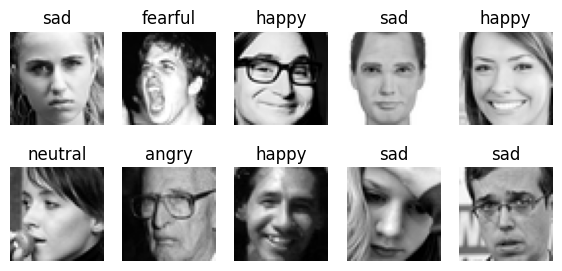

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

for images, labels in train_ds.take(1):
    for i in range(10):
        ax = plt.subplot(3,5,i+1)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')
        plt.title(class_names[tf.argmax(labels[i])])
        plt.axis("off")



# Loading the test data

In [7]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='categorical',
    batch_size=32,                
    image_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',        
    shuffle=True
)

Found 7178 files belonging to 7 classes.


# Binary Class Tranformation

In [8]:
class_names = train_ds.class_names
print(class_names)

distress_classes = ['angry','disgusted','fearful','sad','surprised']

# Create binary lookup tensor
binary_map = []
for name in class_names:
    if name in distress_classes:
        binary_map.append([1.,0.])  # Distress
    else:
        binary_map.append([0.,1.])  # Normal

binary_map = tf.constant(binary_map)
print(binary_map)


['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
tf.Tensor(
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]], shape=(7, 2), dtype=float32)


# Applying Binary Mapping

In [9]:
def map_to_binary(images, labels):

    class_ids = tf.argmax(labels, axis=1)

    new_labels = tf.gather(binary_map, class_ids)

    return images, new_labels

train_ds_binary = train_ds.map(map_to_binary)
test_ds_binary  = test_ds.map(map_to_binary)


# Normalizing the train as well as test data


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

def normalize(images, labels):
    return images/255.0, labels

train_ds_binary = train_ds_binary.map(normalize).prefetch(AUTOTUNE)
test_ds_binary  = test_ds_binary.map(normalize).prefetch(AUTOTUNE)

# Creating A CNN Architecture for model fitting

In [11]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(48,48,1)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(2,activation='softmax')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,098 (1.36 MB)

 Trainable params: 355,650 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

# Compiling the model 

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=[
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        'accuracy'
    ]
)


# Setting early stopping callback function to prevent overfitting of the CNN Model 

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_precision',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-5
)


# Training the model 

In [14]:
history = model.fit(
    train_ds_binary,
    validation_data=test_ds_binary,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30


I0000 00:00:1771428220.614237      76 service.cc:152] XLA service 0x788b74008b00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771428220.614312      76 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771428220.614319      76 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771428221.212583      76 cuda_dnn.cc:529] Loaded cuDNN version 91002


 13/898 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5318 - loss: 1.5974 - precision: 0.5318 - recall: 0.5318

I0000 00:00:1771428225.069272      76 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


898/898 ━━━━━━━━━━━━━━━━━━━━ 49s 47ms/step - accuracy: 0.6264 - loss: 0.7220 - precision: 0.6264 - recall: 0.6264 - val_accuracy: 0.6948 - val_loss: 0.5697 - val_precision: 0.6948 - val_recall: 0.6948 - learning_rate: 0.0010
Epoch 2/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7360 - loss: 0.5207 - precision: 0.7360 - recall: 0.7360 - val_accuracy: 0.6690 - val_loss: 0.6007 - val_precision: 0.6690 - val_recall: 0.6690 - learning_rate: 0.0010
Epoch 3/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7645 - loss: 0.4797 - precision: 0.7645 - recall: 0.7645 - val_accuracy: 0.7538 - val_loss: 0.5033 - val_precision: 0.7538 - val_recall: 0.7538 - learning_rate: 0.0010
Epoch 4/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7903 - loss: 0.4372 - precision: 0.7903 - recall: 0.7903 - val_accuracy: 0.7325 - val_loss: 0.5288 - val_precision: 0.7325 - val_recall: 0.7325 - learning_rate: 0.0010
Epoch 5/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8110 -

# Evaluating on the basis of curves provided by the history function

# Loss Curve

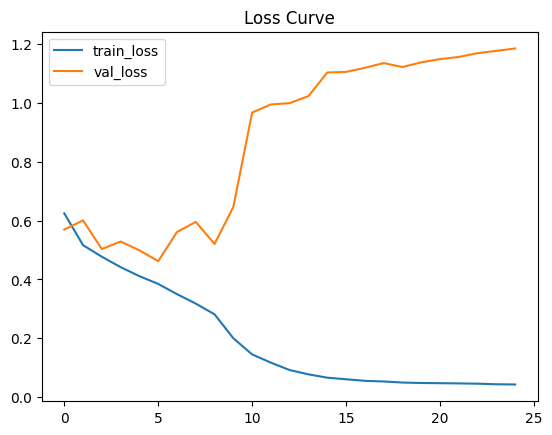

In [15]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

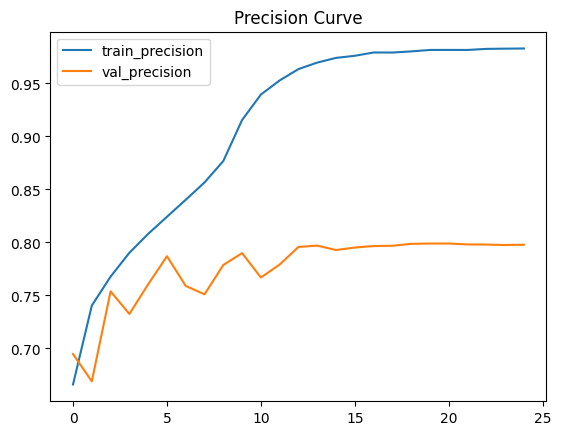

In [16]:
plt.plot(history.history['precision'], label='train_precision')
plt.plot(history.history['val_precision'], label='val_precision')
plt.legend()
plt.title("Precision Curve")
plt.show()

# The above graph clearly shows overfitting occured while training the model

# Fixes to overcome the overfitting 

In [17]:
#Adding a Augmentation layer
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
])

# Adding the augmentation layer in the model

In [18]:
model = models.Sequential([

    layers.Input(shape=(48,48,1)),

    #adding the augmentation layer
    data_aug,

    # Block 1
    layers.Conv2D(32,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    # Reduced Dense size (was 128)
    layers.Dense(64,activation='relu'),

    # Increased Dropout
    layers.Dropout(0.5),

    # Binary Output
    layers.Dense(2,activation='softmax')
])

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=[
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        'accuracy'
    ]
)

# Training the model again after adding the augmentation layer

In [20]:
history = model.fit(
    train_ds_binary,
    validation_data=test_ds_binary,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.5860 - loss: 0.7511 - precision: 0.5860 - recall: 0.5860 - val_accuracy: 0.6052 - val_loss: 0.6834 - val_precision: 0.6052 - val_recall: 0.6052 - learning_rate: 0.0010
Epoch 2/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.6548 - loss: 0.6093 - precision: 0.6548 - recall: 0.6548 - val_accuracy: 0.7090 - val_loss: 0.5823 - val_precision: 0.7090 - val_recall: 0.7090 - learning_rate: 0.0010
Epoch 3/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.6938 - loss: 0.5728 - precision: 0.6938 - recall: 0.6938 - val_accuracy: 0.7198 - val_loss: 0.5398 - val_precision: 0.7198 - val_recall: 0.7198 - learning_rate: 0.0010
Epoch 4/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.7193 - loss: 0.5466 - precision: 0.7193 - recall: 0.7193 - val_accuracy: 0.6853 - val_loss: 0.5864 - val_precision: 0.6853 - val_recall: 0.6853 - learning_rate: 0.0010
Epoch 5/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - 

# Loss Curve and Precision curve

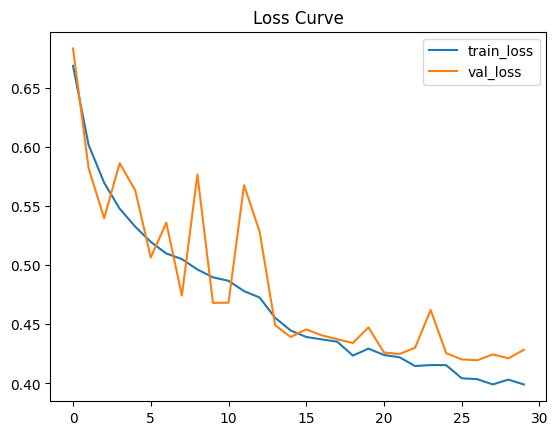

In [21]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

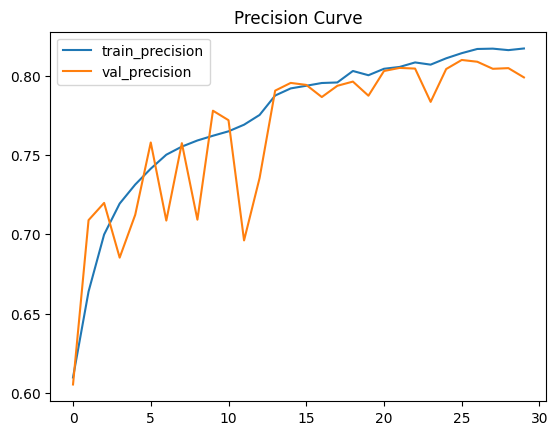

In [22]:
plt.plot(history.history['precision'], label='train_precision')
plt.plot(history.history['val_precision'], label='val_precision')
plt.legend()
plt.title("Precision Curve")
plt.show()

In [23]:
results = model.evaluate(test_ds_binary, verbose=1)
print("Evaluation Results")
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}\n")

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8085 - loss: 0.4245 - precision: 0.8085 - recall: 0.8085
Evaluation Results
loss: 0.4203

compile_metrics: 0.8101



# Now we can conclude that the model is not overfitting as it did earlier but there is a scope for more improvement in the accuracy of the model 

In [24]:
model.save("distress_model_2.h5")
print("Model saved!")


Model saved!


# Creating a pipeline for feeding a RGB image into the model as the model is trained on grayscale image
1) Load the RGB Image
2) 

Prediction: Distress
Confidence: 0.68


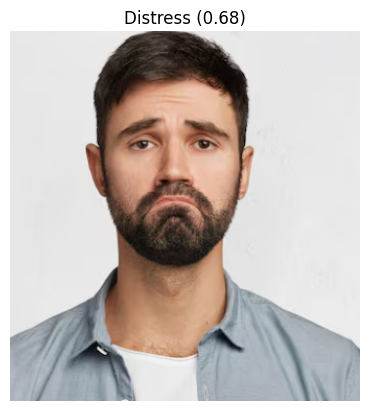

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


img_path = "/kaggle/input/datasets/dasgaurav790/faces/Screenshot 2026-02-18 164431.png"

binary_classes = ["Distress", "Normal"]

#Load RGB image
img = np.array(Image.open(img_path).convert("RGB"))

# -------- Preprocess --------
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
face = cv2.resize(gray, (48,48)) / 255.0
face = face.reshape(1,48,48,1)

#  Predict
pred = model.predict(face, verbose=0)

label = binary_classes[np.argmax(pred)]
conf = np.max(pred)

print("Prediction:", label)
print("Confidence:", round(float(conf),2))

#  Show
plt.imshow(img)
plt.title(f"{label} ({conf:.2f})")
plt.axis("off")
plt.show()


Prediction: Distress
Confidence: 0.75


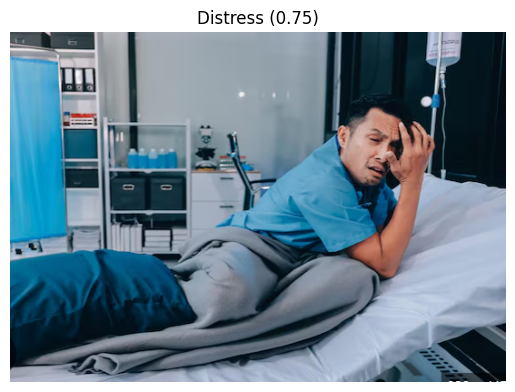

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


img_path = "/kaggle/input/datasets/dasgaurav790/rgb-dataset-raw/Screenshot 2026-02-18 193926.png"

binary_classes = ["Distress", "Normal"]

#  Load RGB image 
img = np.array(Image.open(img_path).convert("RGB"))

# Preprocess
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
face = cv2.resize(gray, (48,48)) / 255.0
face = face.reshape(1,48,48,1)

#Predict
pred = model.predict(face, verbose=0)

label = binary_classes[np.argmax(pred)]
conf = np.max(pred)

print("Prediction:", label)
print("Confidence:", round(float(conf),2))

# Show
plt.imshow(img)
plt.title(f"{label} ({conf:.2f})")
plt.axis("off")
plt.show()


Prediction: Normal | Confidence: 0.98


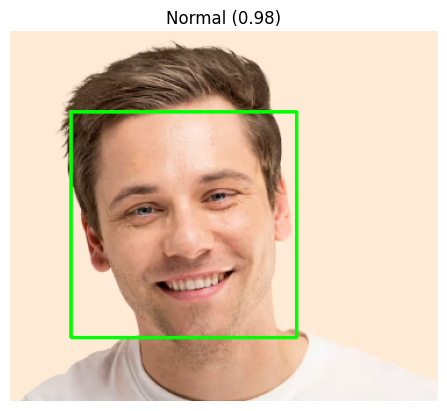

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


img_path = "/kaggle/input/datasets/dasgaurav790/faces/Screenshot 2026-02-18 164511.png"

binary_classes = ["Distress","Normal"]

# Load image
img = np.array(Image.open(img_path).convert("RGB"))
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

#Face detector 
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=3,
    minSize=(80,80)
)


if len(faces) == 0:
    raise ValueError("No face detected in image")


x, y, w, h = faces[0]

#Crop + preprocess
face = gray[y:y+h, x:x+w]
face = cv2.resize(face,(48,48)) / 255.0
face = face.reshape(1,48,48,1)

# Predict 
pred = model.predict(face, verbose=0)
label = binary_classes[np.argmax(pred)]
conf = np.max(pred)

print("Prediction:", label, "| Confidence:", round(float(conf),2))

# Show result
cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)
plt.imshow(img)
plt.title(f"{label} ({conf:.2f})")
plt.axis("off")
plt.show()


Prediction: Distress | Confidence: 0.8


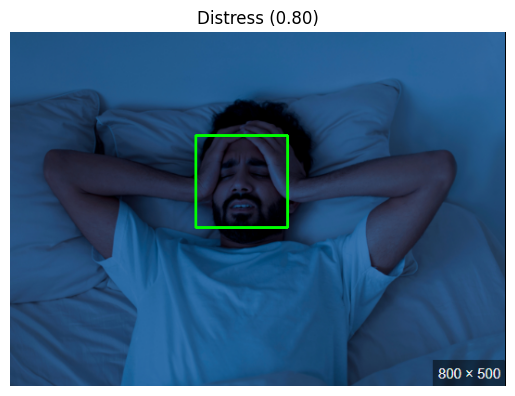

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img_path = "/kaggle/input/datasets/dasgaurav790/rgb-raw-images/Screenshot 2026-02-18 194129.png"

binary_classes = ["Distress","Normal"]

# Load image 
img = np.array(Image.open(img_path).convert("RGB"))
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1, 
    minNeighbors=3,
    minSize=(80,80)
)


if len(faces) == 0:
    raise ValueError("No face detected in image")


x, y, w, h = faces[0]

# Crop + preprocess
face = gray[y:y+h, x:x+w]
face = cv2.resize(face,(48,48)) / 255.0
face = face.reshape(1,48,48,1)

# Predict 
pred = model.predict(face, verbose=0)
label = binary_classes[np.argmax(pred)]
conf = np.max(pred)

print("Prediction:", label, "| Confidence:", round(float(conf),2))

#  Show result
cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)
plt.imshow(img)
plt.title(f"{label} ({conf:.2f})")
plt.axis("off")
plt.show()




Prediction: Normal | Confidence: 0.99


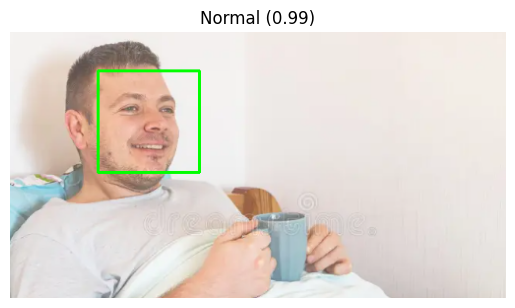

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img_path = "/kaggle/input/datasets/dasgaurav790/happy-patient-rgb/Screenshot 2026-02-18 202903.png"

binary_classes = ["Distress","Normal"]

# Load image 
img = np.array(Image.open(img_path).convert("RGB"))
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1, 
    minNeighbors=3,
    minSize=(80,80)
)


if len(faces) == 0:
    raise ValueError("No face detected in image")


x, y, w, h = faces[0]

# Crop + preprocess
face = gray[y:y+h, x:x+w]
face = cv2.resize(face,(48,48)) / 255.0
face = face.reshape(1,48,48,1)

# Predict 
pred = model.predict(face, verbose=0)
label = binary_classes[np.argmax(pred)]
conf = np.max(pred)

print("Prediction:", label, "| Confidence:", round(float(conf),2))

#  Show result
cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)
plt.imshow(img)
plt.title(f"{label} ({conf:.2f})")
plt.axis("off")
plt.show()




Prediction: Normal | Confidence: 0.87


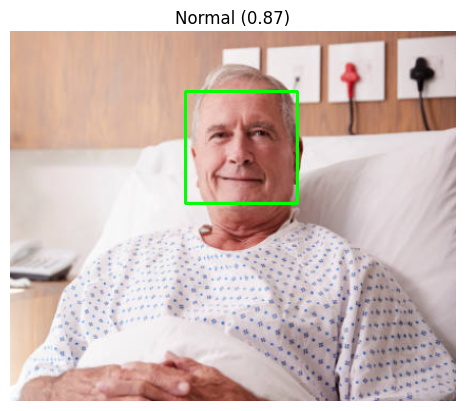

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img_path = "/kaggle/input/datasets/dasgaurav790/happy-patient-rgb/Screenshot 2026-02-18 202913.png"

binary_classes = ["Distress","Normal"]

# Load image 
img = np.array(Image.open(img_path).convert("RGB"))
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1, 
    minNeighbors=3,
    minSize=(80,80)
)


if len(faces) == 0:
    raise ValueError("No face detected in image")


x, y, w, h = faces[0]

# Crop + preprocess
face = gray[y:y+h, x:x+w]
face = cv2.resize(face,(48,48)) / 255.0
face = face.reshape(1,48,48,1)

# Predict 
pred = model.predict(face, verbose=0)
label = binary_classes[np.argmax(pred)]
conf = np.max(pred)

print("Prediction:", label, "| Confidence:", round(float(conf),2))

#  Show result
cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)
plt.imshow(img)
plt.title(f"{label} ({conf:.2f})")
plt.axis("off")
plt.show()


